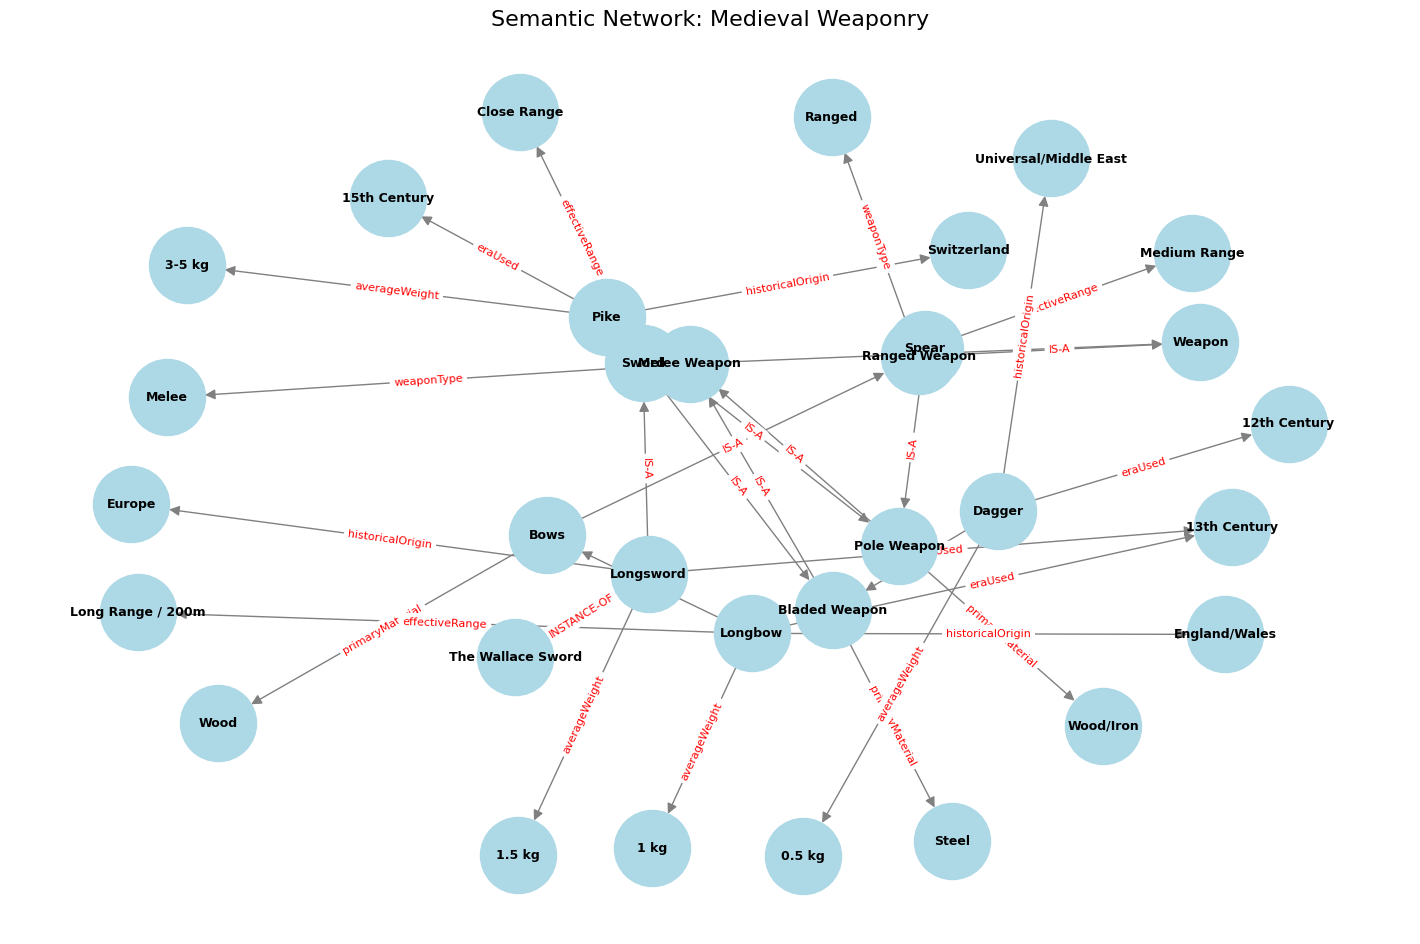

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Initialize a Directed Graph
G = nx.DiGraph()

# 2. Add the Hierarchical Links (Child -> Parent)
taxonomy_links = [
    ("Melee Weapon", "Weapon", "IS-A"),
    ("Bladed Weapon", "Melee Weapon", "IS-A"),
    ("Pole Weapon", "Melee Weapon", "IS-A"),
    ("Sword", "Bladed Weapon", "IS-A"),
    ("Spear", "Pole Weapon", "IS-A"),
    ("Longsword", "Sword", "IS-A"),
    ("The Wallace Sword", "Longsword", "INSTANCE-OF"),
    # Pike (Pole Weapon family)
    ("Pike", "Pole Weapon", "IS-A"),
    
    # Dagger (Bladed Weapon family)
    ("Dagger", "Bladed Weapon", "IS-A"),
    
    # Longbow (Ranged Weapon family - New Branch)
    ("Ranged Weapon", "Weapon", "IS-A"),
    ("Bows", "Ranged Weapon", "IS-A"),
    ("Longbow", "Bows", "IS-A")
]

# Add these edges to the graph
for source, target, rel in taxonomy_links:
    G.add_edge(source, target, label=rel)

# 3. Add the Property Links (Node -> Value)
property_links = [
    ("Melee Weapon", "Melee", "weaponType"),
    ("Bladed Weapon", "Steel", "primaryMaterial"),
    ("Pole Weapon", "Wood/Iron", "primaryMaterial"),
    ("Sword", "Close Range", "effectiveRange"),
    ("Spear", "Medium Range", "effectiveRange"),
    ("Longsword", "1.5 kg", "averageWeight"),
    ("Longsword", "13th Century", "eraUsed"),
    ("Longsword", "Europe", "historicalOrigin"),
    ("Pike", "3-5 kg", "averageWeight"),
    ("Pike", "15th Century", "eraUsed"),
    ("Pike", "Switzerland", "historicalOrigin"),
    # (Inherits 'Medium/Long Range' from Pole Weapon)
    # (Inherits 'Wood/Iron' from Pole Weapon)

    # --- DAGGER ---
    ("Dagger", "0.5 kg", "averageWeight"),
    ("Dagger", "12th Century", "eraUsed"),
    ("Dagger", "Universal/Middle East", "historicalOrigin"),
    # (Inherits 'Close Range' from Bladed Weapon)
    # (Inherits 'Steel' from Bladed Weapon)

    # --- LONGBOW ---
    ("Ranged Weapon", "Ranged", "weaponType"),
    ("Bows", "Wood", "primaryMaterial"),
    ("Longbow", "Long Range / 200m", "effectiveRange"),
    ("Longbow", "1 kg", "averageWeight"),
    ("Longbow", "13th Century", "eraUsed"),
    ("Longbow", "England/Wales", "historicalOrigin")
]

# Add these edges to the graph
for node, value, rel in property_links:
    G.add_edge(node, value, label=rel)

# 4. Visualization
plt.figure(figsize=(14, 9))

# spring_layout uses a force-directed algorithm to position nodes
pos = nx.spring_layout(G, seed=42, k=0.5) 

# Draw the nodes and base edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=3000, font_size=9, font_weight='bold', 
        edge_color='gray', arrows=True, arrowsize=15)

# Draw the specific text labels for the edges (IS-A, weaponType, etc.)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color='red')

plt.title("Semantic Network: Medieval Weaponry", fontsize=16)
plt.axis('off') # Hide the axes
plt.show()

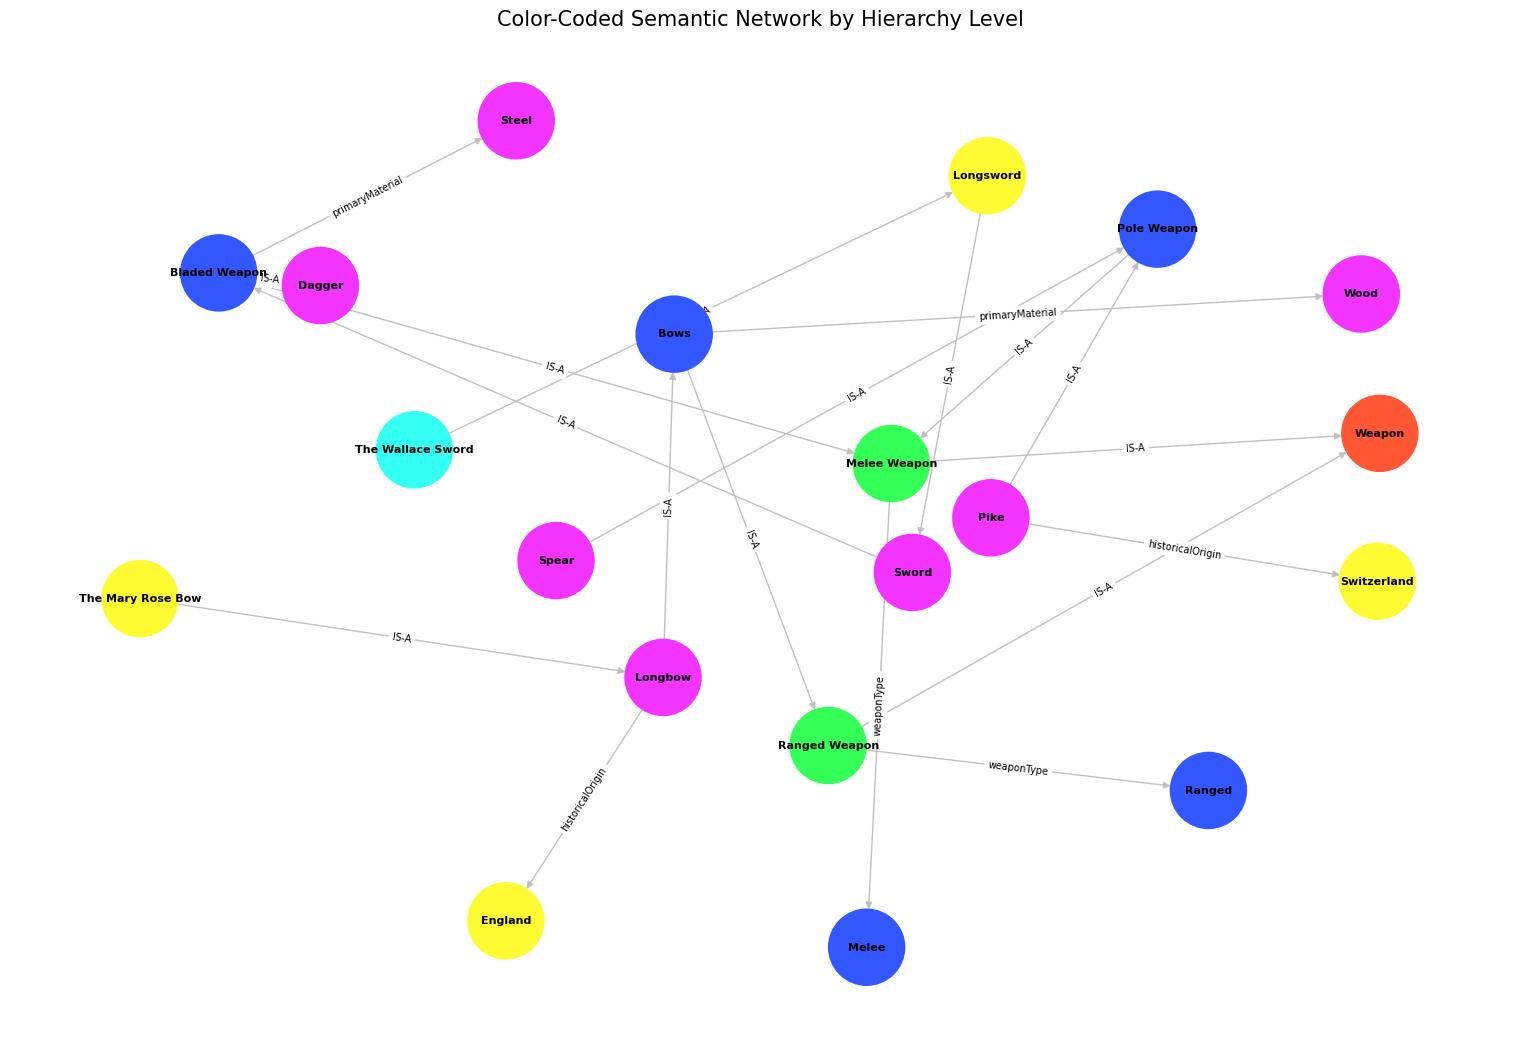

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# 1. Define all Taxonomy Links (Structural)
taxonomy = [
    ("Melee Weapon", "Weapon"), ("Ranged Weapon", "Weapon"),
    ("Bladed Weapon", "Melee Weapon"), ("Pole Weapon", "Melee Weapon"), ("Bows", "Ranged Weapon"),
    ("Sword", "Bladed Weapon"), ("Spear", "Pole Weapon"), ("Dagger", "Bladed Weapon"), ("Pike", "Pole Weapon"), ("Longbow", "Bows"),
    ("The Wallace Sword", "Longsword"), ("Longsword", "Sword"), ("The Mary Rose Bow", "Longbow")
]
G.add_edges_from(taxonomy, label="IS-A")

# 2. Define Property Links (Attributes)
# (Note: Using a separate list to keep the hierarchy clean for distance calculation)
properties = [
    ("Melee Weapon", "Melee", "weaponType"), ("Ranged Weapon", "Ranged", "weaponType"),
    ("Bladed Weapon", "Steel", "primaryMaterial"), ("Bows", "Wood", "primaryMaterial"),
    ("Longbow", "England", "historicalOrigin"), ("Pike", "Switzerland", "historicalOrigin")
]
for u, v, l in properties:
    G.add_edge(u, v, label=l)

# 3. Calculate Levels (Distance from the Root "Weapon")
# We only calculate distance for 'Concept' nodes, not 'Property' nodes to keep colors clean
root = "Weapon"
levels = nx.shortest_path_length(G.to_undirected(), target=root)

# 4. Define a Color Map for 6 levels (0 to 5)
color_palette = {
    0: "#FF5733", # Level 0: Root (Weapon) - Red/Orange
    1: "#33FF57", # Level 1: Category - Green
    2: "#3357FF", # Level 2: Sub-category - Blue
    3: "#F333FF", # Level 3: Family - Purple
    4: "#FFFB33", # Level 4: Specific Type - Yellow
    5: "#33FFF3"  # Level 5: Instance - Cyan
}

# Assign colors to nodes; default to grey if node is a property value not in 'levels'
node_colors = [color_palette.get(levels.get(node, 0), "#D3D3D3") for node in G.nodes()]

# 5. Visualization
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=1.2, seed=42)

nx.draw(G, pos, with_labels=True, node_color=node_colors, 
        node_size=3000, font_size=8, font_weight='bold', 
        edge_color='silver', arrows=True)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("Color-Coded Semantic Network by Hierarchy Level", fontsize=15)
plt.show()

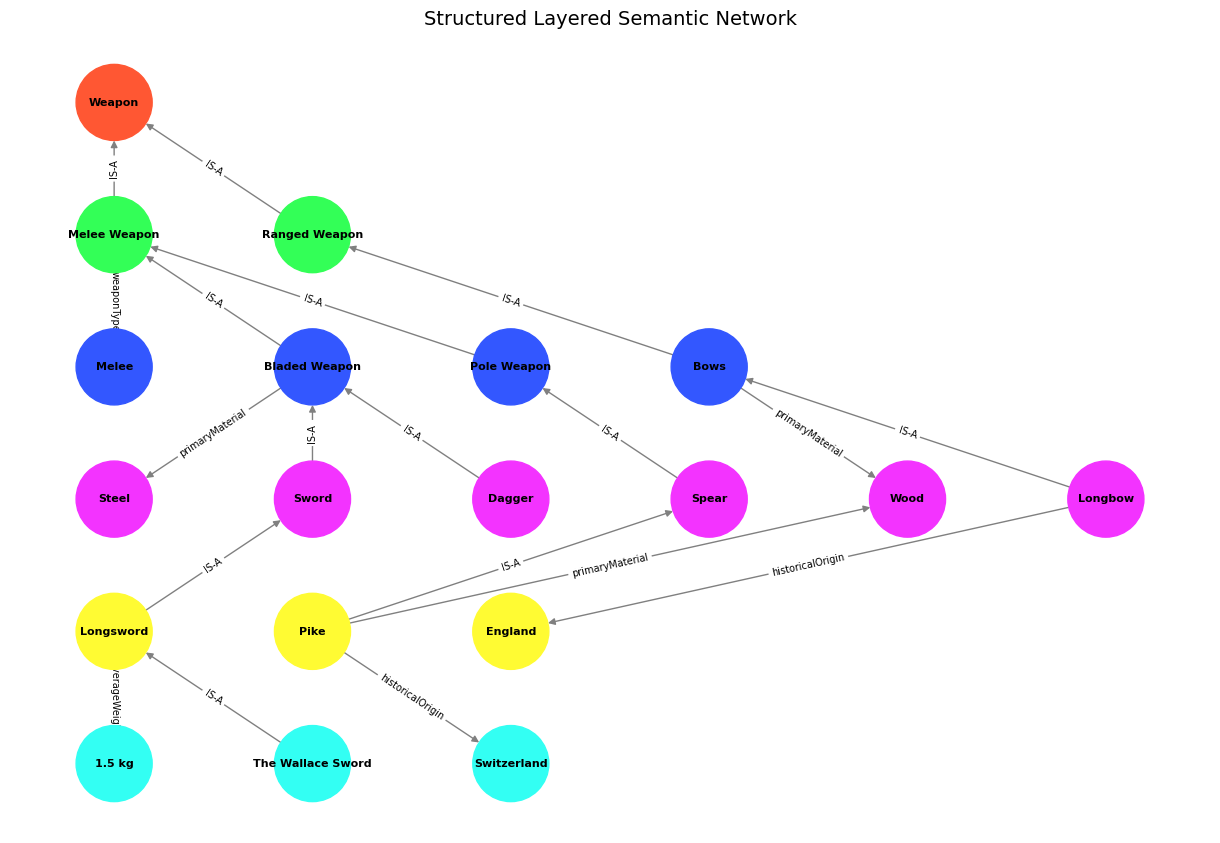

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# 1. Define Taxonomy (Structural Hierarchy)
taxonomy = [
    ("Melee Weapon", "Weapon"), ("Ranged Weapon", "Weapon"),
    ("Bladed Weapon", "Melee Weapon"), ("Pole Weapon", "Melee Weapon"), ("Bows", "Ranged Weapon"),
    ("Sword", "Bladed Weapon"), ("Spear", "Pole Weapon"), ("Dagger", "Bladed Weapon"), ("Pike", "Spear"), ("Longbow", "Bows"),
    ("Longsword", "Sword"), ("The Wallace Sword", "Longsword")
]
G.add_edges_from(taxonomy, label="IS-A")

# 2. Define Properties (Attributes)
properties = [
    ("Melee Weapon", "Melee", "weaponType"),
    ("Bladed Weapon", "Steel", "primaryMaterial"),
    ("Bows", "Wood", "primaryMaterial"),
    ("Pike", "Wood", "primaryMaterial"),
    ("Longbow", "England", "historicalOrigin"),
    ("Pike", "Switzerland", "historicalOrigin"),
    ("Longsword", "1.5 kg", "averageWeight")
]
for u, v, l in properties:
    G.add_edge(u, v, label=l)

# 3. Calculate Levels (Distance from Root)
root = "Weapon"
# We treat it as undirected just to calculate distance easily
dist = nx.shortest_path_length(G.to_undirected(), target=root)

# 4. Manual Positioning Logic
pos = {}
level_counts = {}

for node, level in dist.items():
    # Set Y coordinate based on level (negative so Level 0 is at the top)
    y = -level 
    
    # Set X coordinate to spread nodes at the same level
    level_counts[level] = level_counts.get(level, 0) + 1
    x = level_counts[level]
    
    pos[node] = (x, y)

# 5. Define Color Palette
color_palette = {0: "#FF5733", 1: "#33FF57", 2: "#3357FF", 3: "#F333FF", 4: "#FFFB33", 5: "#33FFF3"}
node_colors = [color_palette.get(dist.get(node, 0), "#D3D3D3") for node in G.nodes()]

# 6. Draw with manual 'pos'
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colors, 
        node_size=3000, font_size=8, font_weight='bold', 
        edge_color='gray', arrows=True)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("Structured Layered Semantic Network", fontsize=14)
plt.show()

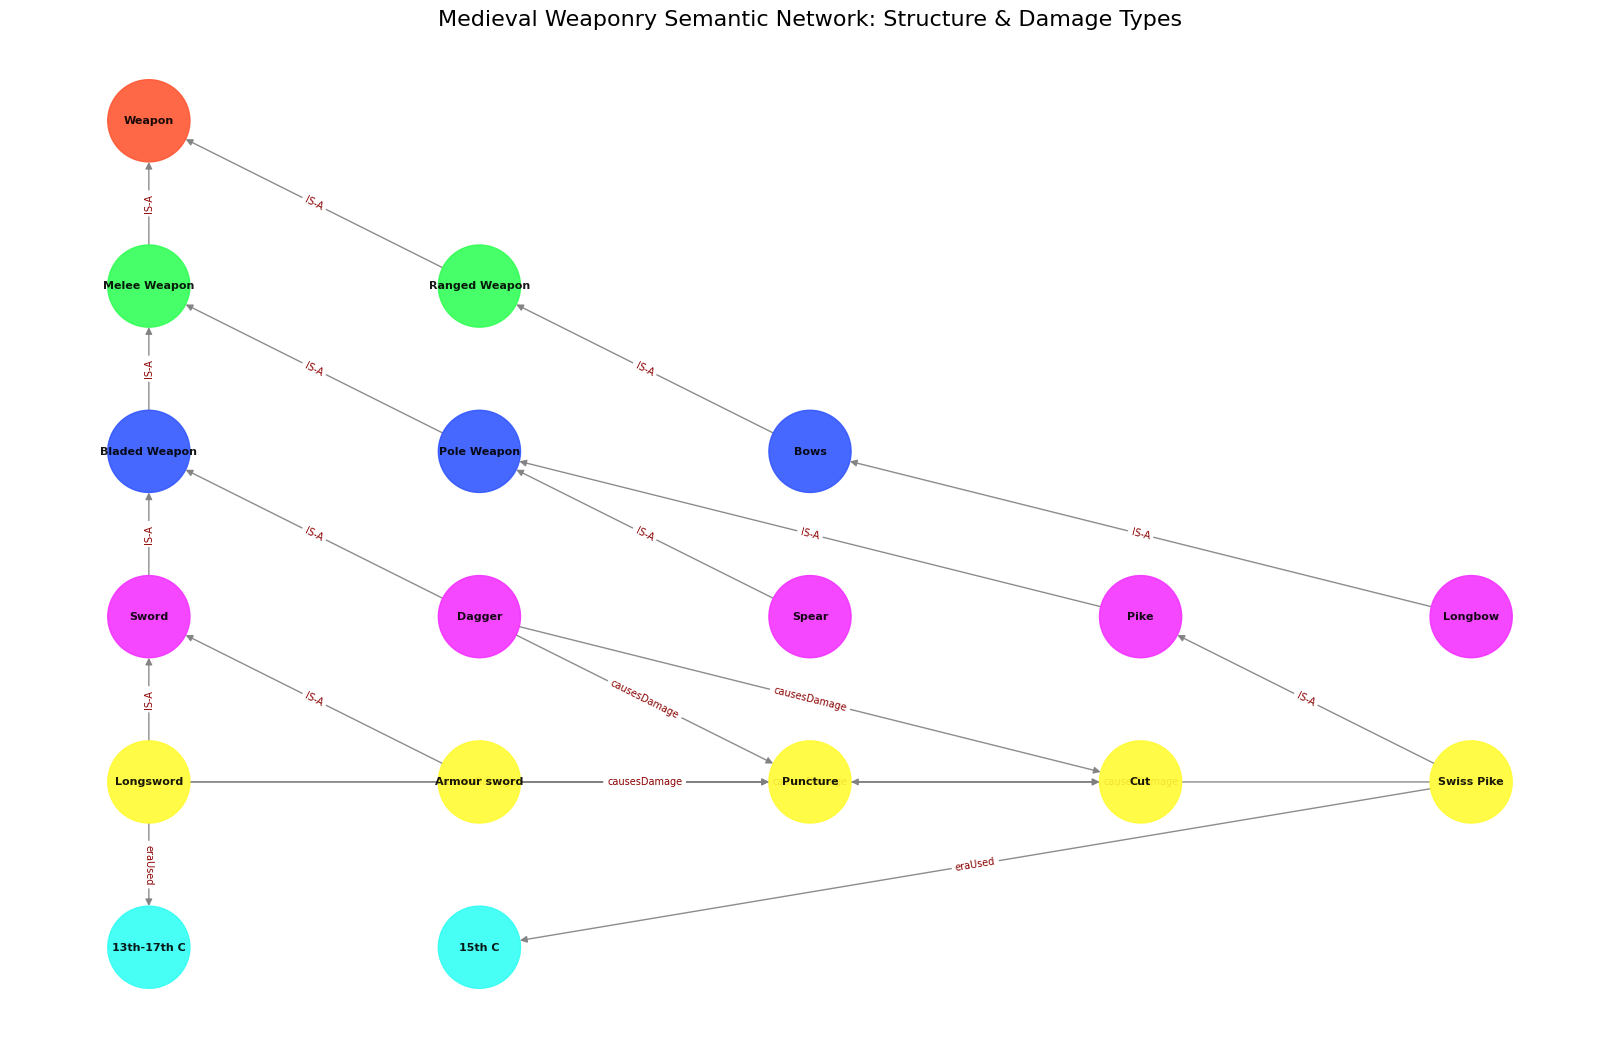

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# 1. Taxonomy (The Tree)
taxonomy = [
    ("Melee Weapon", "Weapon"), ("Ranged Weapon", "Weapon"),
    ("Bladed Weapon", "Melee Weapon"), ("Pole Weapon", "Melee Weapon"), ("Bows", "Ranged Weapon"),
    ("Sword", "Bladed Weapon"), ("Spear", "Pole Weapon"), ("Dagger", "Bladed Weapon"), ("Pike", "Pole Weapon"), ("Longbow", "Bows"),
    ("Longsword", "Sword"), ("Armour sword", "Sword"),
    ("Swiss Pike", "Pike")
]
G.add_edges_from(taxonomy, label="IS-A")

# 2. Properties & Damage (The Data)
data_links = [
    ("Longsword", "13th-17th C", "eraUsed"),
    ("Swiss Pike", "15th C", "eraUsed"),
    # DAMAGE TYPES
    ("Longsword", "Cut", "causesDamage"),
    ("Longsword", "Puncture", "causesDamage"),
    ("Armour sword", "Cut", "causesDamage"),
    ("Armour sword", "Puncture", "causesDamage"),
    ("Swiss Pike", "Puncture", "causesDamage"),
    ("Dagger", "Puncture", "causesDamage"),
    ("Dagger", "Cut", "causesDamage")
]
for u, v, l in data_links:
    G.add_edge(u, v, label=l)

# 3. Enhanced Positioning Logic
# This separates structural nodes from "Attribute" nodes for clarity
root = "Weapon"
dist = nx.shortest_path_length(G.to_undirected(), target=root)

pos = {}
level_counts = {}
for node, level in dist.items():
    y = -level * 2  # Increase vertical spacing
    level_counts[level] = level_counts.get(level, 0) + 1
    x = level_counts[level] * 3 # Increase horizontal spacing
    pos[node] = (x, y)

# 4. Color Palette
# Concepts get colors; specific data values (Damage/Era) get Grey
color_palette = {0: "#FF5733", 1: "#33FF57", 2: "#3357FF", 3: "#F333FF", 4: "#FFFB33", 5: "#33FFF3"}
node_colors = [color_palette.get(dist.get(node, 0), "#D3D3D3") for node in G.nodes()]

# 5. Visualization
plt.figure(figsize=(16, 10))
nx.draw(G, pos, with_labels=True, node_color=node_colors, 
        node_size=3500, font_size=8, font_weight='bold', 
        edge_color='gray', arrows=True, alpha=0.9)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color='darkred')

plt.title("Medieval Weaponry Semantic Network: Structure & Damage Types", fontsize=16)
plt.axis('off')
plt.show()

In [ ]:
import networkx as nx

G = nx.DiGraph()

# 1. Taxonomy (Structure)
taxonomy = [
    ("Melee Weapon", "Weapon"), ("Bladed Weapon", "Melee Weapon"),
    ("Dagger", "Bladed Weapon"), ("Stiletto", "Dagger")
]
G.add_edges_from(taxonomy, label="IS-A")

# 2. Properties (with the Stiletto Override)
props = [
    ("Bladed Weapon", "Cut", "causesDamage"),
    ("Bladed Weapon", "Steel", "primaryMaterial"),
    ("Stiletto", "Puncture", "causesDamage") # Specific override
]
for u, v, l in props:
    G.add_edge(u, v, label=l)

# 3. Level Detection Function
def get_node_details(graph, node_name, root="Weapon"):
    try:
        # Level is the shortest path to the root
        level = nx.shortest_path_length(graph.to_undirected(), source=node_name, target=root)
        
        # Determine properties (Inheritance logic)
        # We look for 'causesDamage' specifically
        damage = "Unknown"
        current = node_name
        while current:
            # Check if current node has a 'causesDamage' link
            edges = graph.out_edges(current, data=True)
            damage_links = [ed[1] for ed in edges if ed[2].get('label') == 'causesDamage']
            
            if damage_links:
                damage = damage_links[0]
                break # Stop here! This is the 'Override'
            
            # Move up the tree (IS-A link)
            parents = [ed[1] for ed in graph.out_edges(current, data=True) if ed[2].get('label') == "IS-A"]
            current = parents[0] if parents else None

        return level, damage
    except nx.NodeNotFound:
        return None, None

# --- TESTING THE LOGIC ---
for weapon in ["Bladed Weapon", "Stiletto"]:
    lvl, dmg = get_node_details(G, weapon)
    print(f"Node: {weapon} | Level: {lvl} | Damage Type: {dmg}")

Node: Bladed Weapon | Level: 2 | Damage Type: Cut
Node: Stiletto | Level: 4 | Damage Type: Puncture


In [ ]:
import networkx as nx
import pandas as pd

# Initialize Graph
G = nx.DiGraph()

# Define structural links (Taxonomy)
taxonomy = [
    ("Melee Weapon", "Weapon"), ("Ranged Weapon", "Weapon"),
    ("Bladed Weapon", "Melee Weapon"), ("Pole Weapon", "Melee Weapon"), ("Bows", "Ranged Weapon"),
    ("Sword", "Bladed Weapon"), ("Spear", "Pole Weapon"), ("Dagger", "Bladed Weapon"), ("Pike", "Pole Weapon"), ("Longbow", "Bows"),
    ("Longsword", "Sword"), ("Stiletto", "Dagger")
]
G.add_edges_from(taxonomy, label="IS-A")

# Define properties with the Stiletto override
properties = [
    ("Melee Weapon", "Melee", "weaponType"),
    ("Bladed Weapon", "Steel", "primaryMaterial"),
    ("Bladed Weapon", "Cut", "causesDamage"), # General Rule
    ("Stiletto", "Puncture", "causesDamage"), # Specific Override
    ("Longsword", "1.5 kg", "averageWeight"),
    ("Pike", "3-5 kg", "averageWeight")
]
for u, v, l in properties:
    G.add_edge(u, v, label=l)

def get_inherited_attribute(graph, node, attribute_label):
    """Recursively climbs the tree to find the first instance of an attribute."""
    current = node
    while current:
        # Check current node for the attribute
        for _, neighbor, data in graph.out_edges(current, data=True):
            if data.get('label') == attribute_label:
                return neighbor
        # Move up the 'IS-A' link
        parents = [target for _, target, data in graph.out_edges(current, data=True) if data.get('label') == "IS-A"]
        current = parents[0] if parents else None
    return "N/A"

# Generate the data for the table
results = []
for node in [n for n, d in G.in_degree() if d >= 0]: # All concept nodes
    # Level = distance to root "Weapon"
    try:
        level = nx.shortest_path_length(G.to_undirected(), source=node, target="Weapon")
        results.append({
            "Node": node,
            "Level": level,
            "Damage Type": get_inherited_attribute(G, node, "causesDamage"),
            "Material": get_inherited_attribute(G, node, "primaryMaterial"),
            "Weight": get_inherited_attribute(G, node, "averageWeight")
        })
    except: continue

# Display as a Table
df = pd.DataFrame(results).sort_values(by="Level")
print(df.to_string(index=False))



         Node  Level Damage Type Material Weight
       Weapon      0         N/A      N/A    N/A
 Melee Weapon      1         N/A      N/A    N/A
Ranged Weapon      1         N/A      N/A    N/A
Bladed Weapon      2         Cut    Steel    N/A
  Pole Weapon      2         N/A      N/A    N/A
         Bows      2         N/A      N/A    N/A
        Melee      2         N/A      N/A    N/A
        Sword      3         Cut    Steel    N/A
        Spear      3         N/A      N/A    N/A
       Dagger      3         Cut    Steel    N/A
      Longbow      3         N/A      N/A    N/A
         Pike      3         N/A      N/A 3-5 kg
          Cut      3         N/A      N/A    N/A
        Steel      3         N/A      N/A    N/A
    Longsword      4         Cut    Steel 1.5 kg
     Stiletto      4    Puncture    Steel    N/A
       3-5 kg      4         N/A      N/A    N/A
     Puncture      5         N/A      N/A    N/A
       1.5 kg      5         N/A      N/A    N/A


--- Hierarchy and Inheritance Table ---
           Entity  Level    Damage  Material      Type
           Weapon      0 Inherited Inherited Inherited
     Melee Weapon      1 Inherited Inherited     Melee
    Ranged Weapon      1 Inherited Inherited Inherited
    Bladed Weapon      2       Cut     Steel     Melee
      Pole Weapon      2 Inherited Inherited     Melee
             Bows      2 Inherited Inherited Inherited
            Melee      2 Inherited Inherited Inherited
            Sword      3       Cut     Steel     Melee
            Spear      3 Inherited Inherited     Melee
           Dagger      3       Cut     Steel     Melee
          Longbow      3 Inherited Inherited Inherited
             Pike      3 Inherited Inherited     Melee
            Steel      3 Inherited Inherited Inherited
              Cut      3 Inherited Inherited Inherited
         Stiletto      4  Puncture     Steel     Melee
        Longsword      4       Cut     Steel     Melee
The Wallace Sword      5 

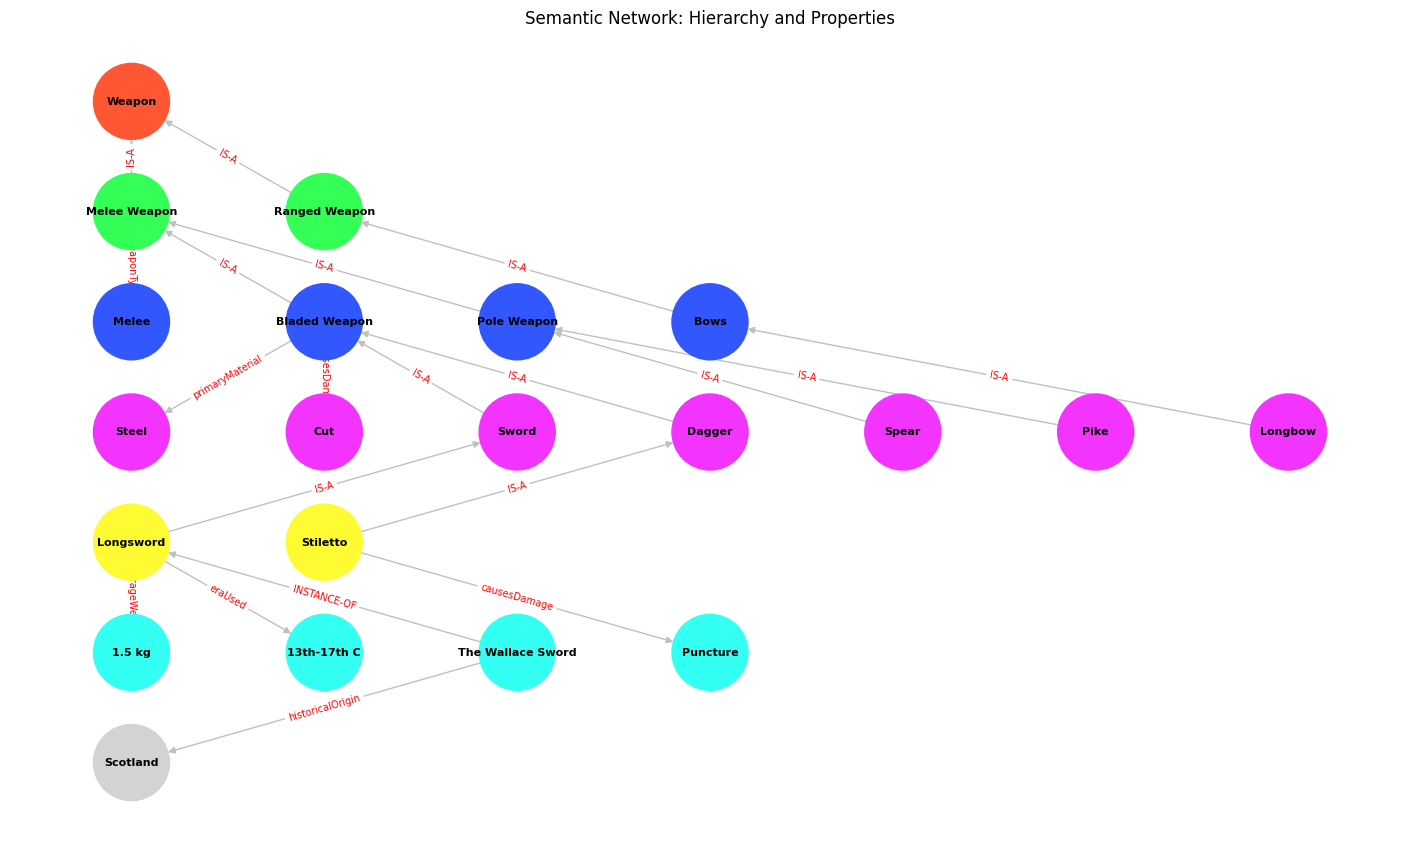

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

def build_weapon_network():
    """Defines the nodes and links for the Medieval Weaponry domain."""
    G = nx.DiGraph()
    
    # 1. Taxonomy (IS-A Hierarchy) - Defines the 'levels'
    taxonomy = [
        ("Melee Weapon", "Weapon", "IS-A"),
        ("Ranged Weapon", "Weapon", "IS-A"),
        ("Bladed Weapon", "Melee Weapon", "IS-A"),
        ("Pole Weapon", "Melee Weapon", "IS-A"),
        ("Bows", "Ranged Weapon", "IS-A"),
        ("Sword", "Bladed Weapon", "IS-A"),
        ("Spear", "Pole Weapon", "IS-A"),
        ("Dagger", "Bladed Weapon", "IS-A"),
        ("Pike", "Pole Weapon", "IS-A"),
        ("Longbow", "Bows", "IS-A"),
        ("Longsword", "Sword", "IS-A"),
        ("Stiletto", "Dagger", "IS-A"),
        ("The Wallace Sword", "Longsword", "INSTANCE-OF") # Level 5 Instance
    ]
    
    # 2. Properties (Attributes and Overrides)
    properties = [
        ("Melee Weapon", "Melee", "weaponType"),
        ("Bladed Weapon", "Steel", "primaryMaterial"),
        ("Bladed Weapon", "Cut", "causesDamage"),
        ("Stiletto", "Puncture", "causesDamage"), # Overrides 'Cut'
        ("Longsword", "1.5 kg", "averageWeight"),
        ("Longsword", "13th-17th C", "eraUsed"),
        ("The Wallace Sword", "Scotland", "historicalOrigin")
    ]

    # Add all edges to the graph
    for u, v, l in taxonomy + properties:
        G.add_edge(u, v, label=l)
        
    return G

def get_inherited_attr(graph, node, attribute_label):
    """Climbs the 'IS-A' hierarchy to find an inherited property."""
    current = node
    while current:
        # Check current node's outgoing edges for the attribute
        for _, neighbor, data in graph.out_edges(current, data=True):
            if data.get('label') == attribute_label:
                return neighbor
        # Move up the hierarchy
        parents = [target for _, target, data in graph.out_edges(current, data=True) 
                   if data.get('label') in ["IS-A", "INSTANCE-OF"]]
        current = parents[0] if parents else None
    return "Inherited"

def draw_semantic_network(graph, root_node="Weapon"):
    """Draws a color-coded, layered representation of the network."""
    # Calculate levels based on distance from root
    dist = nx.shortest_path_length(graph.to_undirected(), target=root_node)
    
    # Create Layered Position (Y = Level, X = Spread)
    pos = {}
    level_counts = {}
    for node, level in dist.items():
        level_counts[level] = level_counts.get(level, 0) + 1
        pos[node] = (level_counts[level] * 4, -level * 2)

    # Map colors to levels 0 through 5
    palette = {0:"#FF5733", 1:"#33FF57", 2:"#3357FF", 3:"#F333FF", 4:"#FFFB33", 5:"#33FFF3"}
    node_colors = [palette.get(dist.get(n, 0), "#D3D3D3") for n in graph.nodes()]

    plt.figure(figsize=(14, 8))
    nx.draw(graph, pos, with_labels=True, node_color=node_colors, 
            node_size=3000, font_size=8, font_weight='bold', edge_color='silver')
    
    edge_labels = nx.get_edge_attributes(graph, 'label')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7, font_color='red')
    
    plt.title(f"Semantic Network: Hierarchy and Properties")
    plt.show()

def list_network_logic(graph, root_node="Weapon"):
    """Generates a DataFrame showing levels and inherited logic."""
    data = []
    # Identify concepts (nodes that have IS-A or INSTANCE-OF links)
    concepts = [n for n, d in graph.in_degree() if d >= 0]
    
    for node in concepts:
        try:
            level = nx.shortest_path_length(graph.to_undirected(), source=node, target=root_node)
            data.append({
                "Entity": node,
                "Level": level,
                "Damage": get_inherited_attr(graph, node, "causesDamage"),
                "Material": get_inherited_attr(graph, node, "primaryMaterial"),
                "Type": get_inherited_attr(graph, node, "weaponType")
            })
        except: continue

    df = pd.DataFrame(data).sort_values("Level")
    print(df.to_string(index=False))

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Build
    my_network = build_weapon_network()
    
    # 2. List (Logic check)
    print("--- Hierarchy and Inheritance Table ---")
    list_network_logic(my_network, root_node="Weapon")
    
    # 3. Draw (Visual check)
    draw_semantic_network(my_network, root_node="Weapon")